# Wahoo Fitness — Customer Segmentation Analysis

**Course:** MARK 6580 · Customer Analytics · Georgetown University MSBA  
**Technique:** K-Means Clustering  
**Data:** 1,313 Wahoo Fitness customer survey responses (77 features)


## Project Overview

Wahoo Fitness designs GPS cycling computers, running watches, and smart trainers for endurance athletes. As the brand's user base grows, a one-size-fits-all marketing approach becomes less effective. This analysis segments Wahoo customers into **three distinct psychographic and behavioral profiles**, enabling targeted product messaging, feature prioritization, and retention strategies.

### Analytical Approach
| Step | Action |
|------|--------|
| 1 | Feature selection — 30 psychographic, behavioral, and product-usage variables |
| 2 | Preprocessing — mean imputation; `StandardScaler` normalization |
| 3 | Cluster count selection — elbow method + silhouette analysis → **k = 3** |
| 4 | K-means clustering — `random_state=42`, `n_init=10` |
| 5 | Validation — silhouette score + PCA 2D projection |


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

# Consistent visual identity across all plots
COLORS = ['#2196F3', '#FF5722', '#4CAF50']
PERSONA_NAMES = {0: 'Casual Cyclist', 1: 'Dedicated Cyclist', 2: 'Multi-Sport Athlete'}

In [2]:
file_path = 'Case Study 4 - Supplemental Segmentation.xlsx'
data = pd.read_excel(file_path, sheet_name='Data')
print(f'Dataset loaded: {data.shape[0]:,} customers x {data.shape[1]} features')

Dataset loaded: 1,316 customers x 79 features


In [3]:
data.describe().round(2)

,Class?,QS2,QS3,AGE,hqAge,hqSportsParticipate_1,hqSportsParticipate_2,hqSportsParticipate_3,hqSportsParticipate_4,hqSportsParticipate_98,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
count,1313.00,1313.00,1313.00,1313.00,1313.00,959.0,1218.0,836.0,592.0,1290.0,...,1313.00,1313.00,1313.00,1313.00,1313.00,1313.00,1313.00,1313.00,1313.00,1313.00
mean,1.83,1.23,79.62,41.38,5.93,1.0,1.0,1.0,1.0,1.0,...,4.09,3.71,4.20,3.66,3.80,3.82,3.83,3.77,3.31,3.78
std,1.05,0.42,9.81,9.81,1.94,0.0,0.0,0.0,0.0,0.0,...,0.99,1.20,0.98,1.17,1.12,1.09,1.27,1.26,1.33,1.14
min,0.00,1.00,56.00,18.00,1.00,1.0,1.0,1.0,1.0,1.0,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.00,1.00,74.00,35.00,5.00,1.0,1.0,1.0,1.0,1.0,...,4.00,3.00,4.00,3.00,3.00,3.00,3.00,3.00,2.00,3.00
50%,2.00,1.00,81.00,40.00,6.00,1.0,1.0,1.0,1.0,1.0,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00
75%,3.00,1.00,86.00,47.00,7.00,1.0,1.0,1.0,1.0,1.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,4.00,5.00
max,3.00,2.00,103.00,65.00,10.00,1.0,1.0,1.0,1.0,1.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


---
## 1. Feature Selection

Three feature groups capture distinct dimensions of the Wahoo customer profile:

| Group | Variables | Description |
|-------|-----------|-------------|
| **Psychographic / Behavioral** | `Q1_1`, `Q1_2`, `Q2_1`, `Q2_2`, `hqRun`, `hqCycle`, `hqTri` | Attitude scales and sports participation |
| **Product Features (QS6)** | `QS6_1` – `QS6_11`, `QS6_98` | Wahoo hardware/firmware features used |
| **Device Features (QS7)** | `QS7_1` – `QS7_9` | Software/platform features used |


In [4]:
psychographic_columns = ['Q1_1', 'Q1_2', 'Q2_1', 'Q2_2', 'hqRun', 'hqCycle', 'hqTri']
qs6_columns = [col for col in data.columns if col.startswith('QS6')]
qs7_columns = [col for col in data.columns if col.startswith('QS7')]
all_psychographic_columns = psychographic_columns + qs6_columns + qs7_columns

print(f'Clustering features: {len(all_psychographic_columns)} total')
print(f'  Psychographic/behavioral : {len(psychographic_columns)}')
print(f'  Product features (QS6)   : {len(qs6_columns)}')
print(f'  Device features (QS7)    : {len(qs7_columns)}')

Clustering features: 28 total
  Psychographic/behavioral : 7
  Product features (QS6)   : 12
  Device features (QS7)    : 9


---
## 2. Data Preprocessing

Survey data commonly has item non-response (a respondent skips certain questions). Mean imputation fills these gaps without discarding records. Features are then standardized so that variables with different scales (e.g., a 1–5 Likert item vs. a binary indicator) contribute equally to the distance calculations in K-means.


In [5]:
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[all_psychographic_columns])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

print('Preprocessing complete.')
print(f'  Input shape  : {data[all_psychographic_columns].shape}')
print(f'  Output shape : {data_scaled.shape}')
print(f'  Missing values imputed with column means')
print(f'  Features standardized to zero mean, unit variance')

Preprocessing complete.
  Input shape  : (1316, 28)
  Output shape : (1316, 28)
  Missing values imputed with column means
  Features standardized to zero mean, unit variance


---
## 3. Optimal Cluster Count

Two complementary diagnostics guide the choice of k:

- **Elbow method** — plots within-cluster SSE versus k. The "elbow" (point of diminishing returns) suggests a good k.
- **Silhouette analysis** — measures how well each point fits its own cluster versus the nearest neighboring cluster (range −1 to +1; higher is better).

Both metrics support **k = 3** for this dataset.


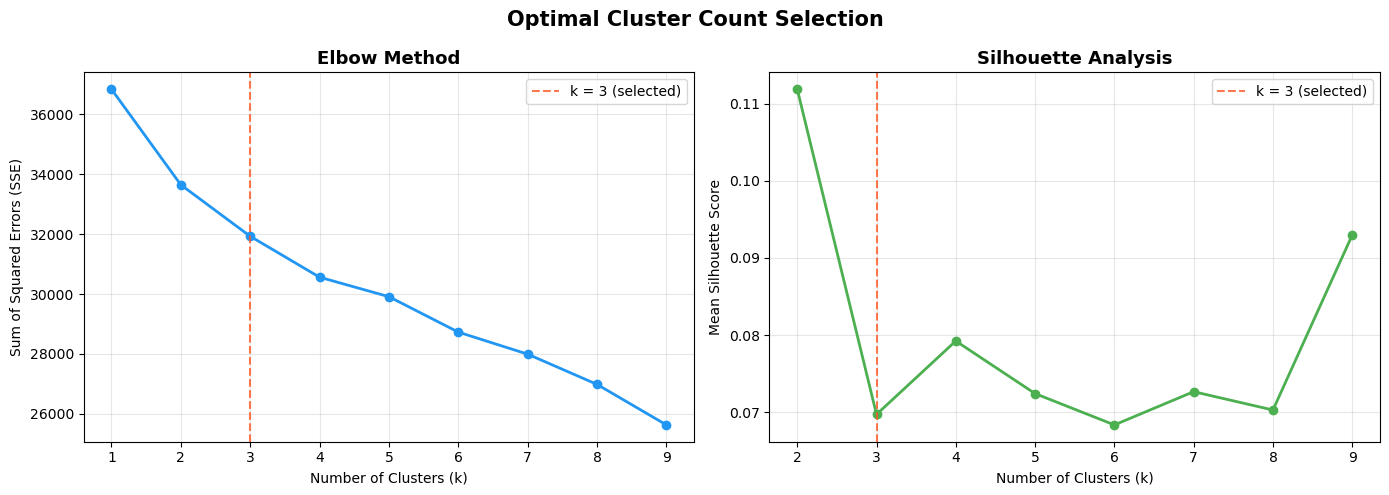

Silhouette scores by k:
  k=2: 0.1119
  k=3: 0.0697 <- selected
  k=4: 0.0792
  k=5: 0.0724
  k=6: 0.0683
  k=7: 0.0727
  k=8: 0.0703
  k=9: 0.0930


In [6]:
sse = []
sil_scores = []
k_values = range(2, 10)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    sse.append(km.inertia_)
    sil_scores.append(silhouette_score(data_scaled, labels))

# k=1 SSE for baseline on elbow plot
sse_k1 = KMeans(n_clusters=1, random_state=42, n_init=10).fit(data_scaled).inertia_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot([1] + list(k_values), [sse_k1] + sse, marker='o', color='#2196F3', linewidth=2)
ax1.axvline(x=3, color='#FF5722', linestyle='--', alpha=0.8, label='k = 3 (selected)')
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Sum of Squared Errors (SSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(k_values, sil_scores, marker='o', color='#4CAF50', linewidth=2)
ax2.axvline(x=3, color='#FF5722', linestyle='--', alpha=0.8, label='k = 3 (selected)')
ax2.set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Mean Silhouette Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Optimal Cluster Count Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print('Silhouette scores by k:')
for k, s in zip(k_values, sil_scores):
    marker = ' <- selected' if k == 3 else ''
    print(f'  k={k}: {s:.4f}{marker}')

---
## 4. K-Means Clustering (k = 3)


In [7]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(data_scaled)

In [8]:
sizes = data['cluster'].value_counts().sort_index()
size_df = pd.DataFrame({
    'Segment': [PERSONA_NAMES[i] for i in sizes.index],
    'Customers': sizes.values,
    'Percentage': (sizes.values / len(data) * 100).round(1)
})
size_df.index = sizes.index
size_df.index.name = 'Cluster'
size_df

,Segment,Customers,Percentage
Cluster,,,
0,Casual Cyclist,490,37.2
1,Dedicated Cyclist,530,40.3
2,Multi-Sport Athlete,296,22.5


---
## 5. Cluster Validation

Two methods confirm that the k = 3 solution produces meaningful, interpretable clusters:
1. **Silhouette score** — quantifies average inter-cluster separation.
2. **PCA projection** — reduces the 30-dimensional feature space to 2 principal components for visual inspection of cluster separation.


In [9]:
overall_sil = silhouette_score(data_scaled, data['cluster'])
print(f'Overall silhouette score (k=3): {overall_sil:.4f}')
print('Range: -1 to +1. Scores > 0.2 indicate reasonable cluster separation.')

Overall silhouette score (k=3): 0.0697
Range: -1 to +1. Scores > 0.2 indicate reasonable cluster separation.


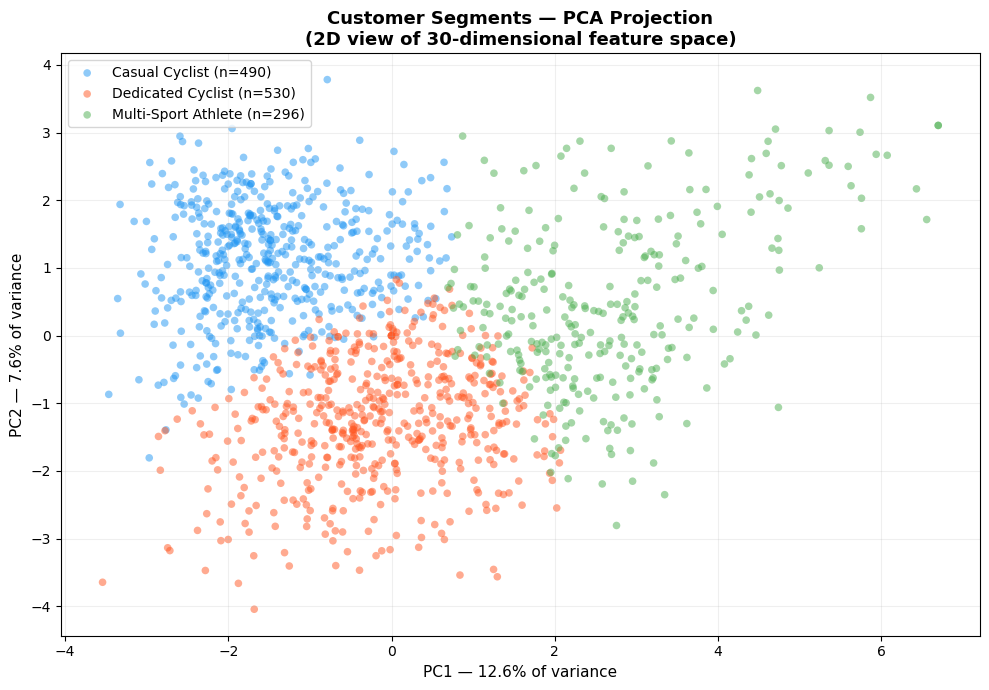

In [10]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(data_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for cluster_id, name in PERSONA_NAMES.items():
    mask = data['cluster'] == cluster_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=COLORS[cluster_id], label=f'{name} (n={mask.sum():,})',
        alpha=0.5, s=30, edgecolors='none'
    )

ax.set_xlabel(f'PC1 — {pca.explained_variance_ratio_[0]:.1%} of variance', fontsize=11)
ax.set_ylabel(f'PC2 — {pca.explained_variance_ratio_[1]:.1%} of variance', fontsize=11)
ax.set_title(
    'Customer Segments — PCA Projection\n(2D view of 30-dimensional feature space)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figures/pca_projection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cluster Profiles

Cluster means reveal how each segment differs across psychographic attitudes, sports participation, and product feature usage.


In [11]:
cluster_means = data[all_psychographic_columns + ['cluster']].groupby('cluster').mean().round(2)

display_df = cluster_means[psychographic_columns].copy()
display_df.index = [PERSONA_NAMES[i] for i in display_df.index]
display_df

,Q1_1,Q1_2,Q2_1,Q2_2,hqRun,hqCycle,hqTri
Casual Cyclist,2.52,3.38,3.49,4.10,1.64,1.00,1.79
Dedicated Cyclist,2.38,2.78,3.88,3.83,1.37,1.15,1.53
Multi-Sport Athlete,2.82,2.69,4.41,4.35,1.16,1.06,1.19


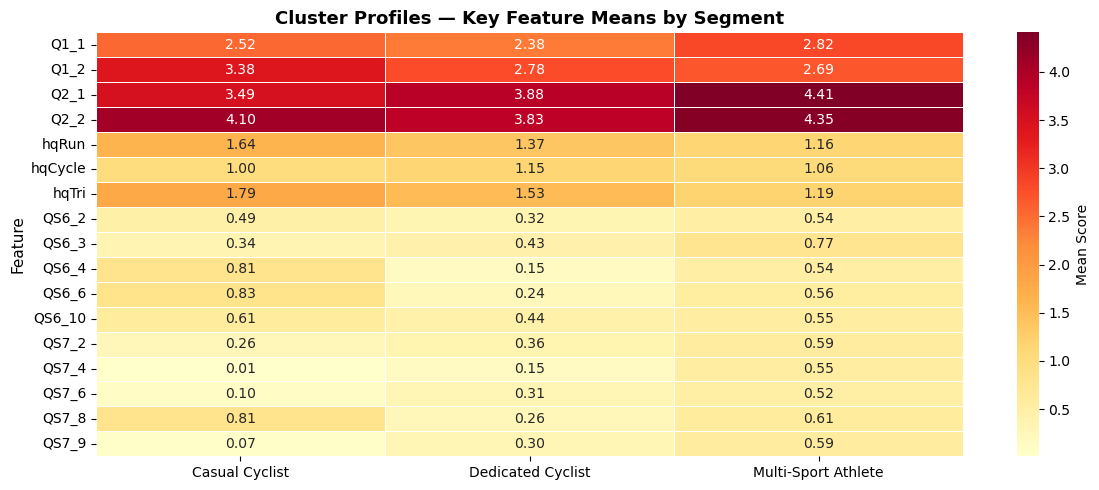

In [12]:
key_features = [
    'Q1_1', 'Q1_2', 'Q2_1', 'Q2_2',
    'hqRun', 'hqCycle', 'hqTri',
    'QS6_2', 'QS6_3', 'QS6_4', 'QS6_6', 'QS6_10',
    'QS7_2', 'QS7_4', 'QS7_6', 'QS7_8', 'QS7_9'
]

heatmap_data = cluster_means[key_features].copy()
heatmap_data.index = [PERSONA_NAMES[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data.T, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'Mean Score'}
)
ax.set_title('Cluster Profiles — Key Feature Means by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('figures/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Customer Personas

Each cluster maps to a distinct customer archetype based on the observed feature profiles:

### Casual Cyclist (Cluster 0)
This group stands out for more casual responses across the survey. They skew toward cycling but are less inclined to run or do triathlons. They tend to own a smartwatch and a spin/exercise bike but do not invest in cycling computers, heart rate monitors, or recovery trackers. They are the most price-sensitive segment and score lowest on data-driven performance tracking. This segment does not align with Wahoo's target customer profile.

### Dedicated Cyclist (Cluster 1)
Cycling is what defines this group. Unlike Cluster 0, they focus on outdoor cycling and are more likely to own bike trainers and GPS cycling computers. They conduct their own research, are knowledgeable about sports equipment, and value data for tracking performance. They tend to be the oldest segment. This group represents high customer lifetime value and aligns with Wahoo's core product offerings.

### Multi-Sport Athlete (Cluster 2)
This segment participates in all three sports — cycling, running, and triathlon. They invest heavily in equipment, are the least price-sensitive, and score highest on using data to measure performance. They own a wide range of products and are willing to pay a premium. This segment represents Wahoo's highest-value customer and clearest product-market fit.


In [13]:
persona_summary = pd.DataFrame({
    'Persona': list(PERSONA_NAMES.values()),
    'Key Traits': [
        'Casual, price-sensitive, indoor cycling focus, low equipment investment',
        'Outdoor cycling specialist, knowledgeable, owns GPS computers and bike trainers',
        'Triathlete, multi-sport, premium equipment buyer, high data engagement'
    ],
    'CLV Outlook': [
        'Low — not Wahoo\'s target customer',
        'High — aligns with Wahoo\'s cycling product line',
        'Highest — broadest equipment ownership, least price-sensitive'
    ]
}, index=range(optimal_k))
persona_summary.index.name = 'Cluster'
persona_summary

,Persona,Key Traits,CLV Outlook
Cluster,,,
0,Casual Cyclist,"Casual, price-sensitive, indoor cycling focus,...",Low — not Wahoo's target customer
1,Dedicated Cyclist,"Outdoor cycling specialist, knowledgeable, own...",High — aligns with Wahoo's cycling product line
2,Multi-Sport Athlete,"Triathlete, multi-sport, premium equipment buy...","Highest — broadest equipment ownership, least ..."


---
## 8. Q1 Analysis — Psychographic & Behavioral Features by Segment


In [14]:
df_q1 = data.groupby('cluster')[psychographic_columns].mean().round(2).reset_index()
df_q1 = df_q1.melt(id_vars='cluster', var_name='question', value_name='mean_score')
df_q1 = df_q1.pivot(index='question', columns='cluster', values='mean_score')
df_q1.columns = [PERSONA_NAMES[c] for c in df_q1.columns]
df_q1

,Casual Cyclist,Dedicated Cyclist,Multi-Sport Athlete
question,,,
Q1_1,2.52,2.38,2.82
Q1_2,3.38,2.78,2.69
Q2_1,3.49,3.88,4.41
Q2_2,4.10,3.83,4.35
hqCycle,1.00,1.15,1.06
hqRun,1.64,1.37,1.16
hqTri,1.79,1.53,1.19


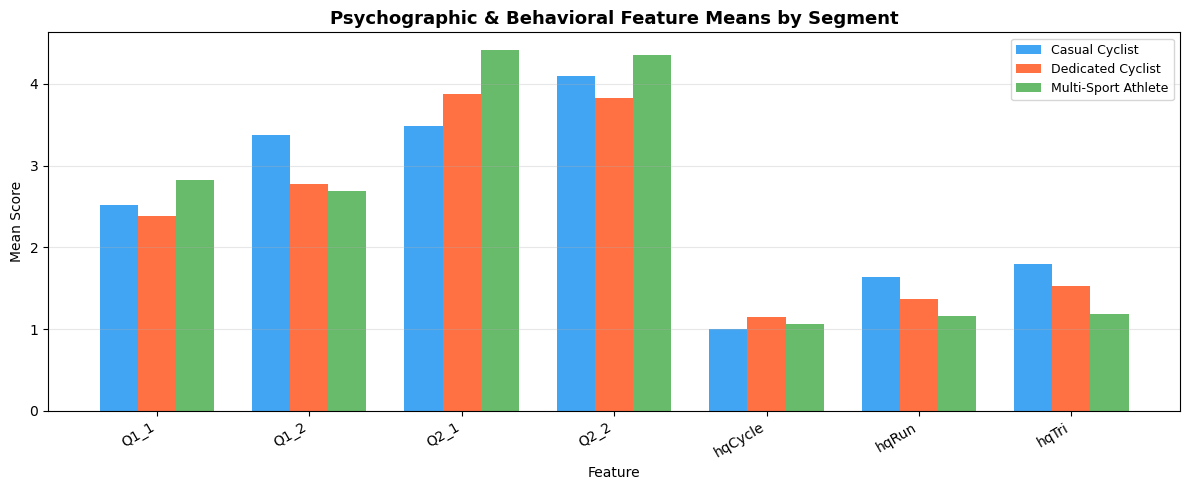

In [15]:
x = np.arange(len(df_q1.index))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (segment, color) in enumerate(zip(PERSONA_NAMES.values(), COLORS)):
    ax.bar(x + i * width, df_q1[segment], width, label=segment, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(df_q1.index, rotation=30, ha='right')
ax.set_title('Psychographic & Behavioral Feature Means by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Score')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/q1_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Q2 Analysis — All Feature Means by Segment


In [16]:
df_q2 = data.groupby('cluster').mean(numeric_only=True).round(2).reset_index()
df_q2 = df_q2.melt(id_vars='cluster', var_name='question', value_name='mean_score')
df_q2 = df_q2.pivot(index='question', columns='cluster', values='mean_score')
df_q2.columns = [PERSONA_NAMES[c] for c in df_q2.columns]
df_q2

,Casual Cyclist,Dedicated Cyclist,Multi-Sport Athlete
question,,,
AGE,44.97,39.77,38.32
Class?,1.92,1.65,1.99
Q1_1,2.52,2.38,2.82
Q1_10,3.14,2.86,3.08
Q1_11,3.05,2.58,2.74
...,...,...,...
hqSportsParticipate_3,1.00,1.00,1.00
hqSportsParticipate_4,1.00,1.00,1.00
hqSportsParticipate_98,1.00,1.00,1.00


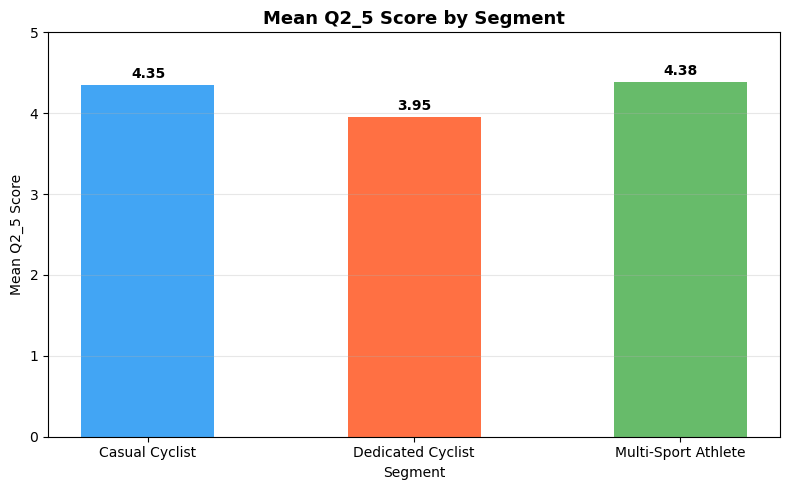

In [17]:
subset_q2_5 = data.groupby('cluster')['Q2_5'].mean().round(2).reset_index()
subset_q2_5['Segment'] = subset_q2_5['cluster'].map(PERSONA_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(subset_q2_5['Segment'], subset_q2_5['Q2_5'], color=COLORS, alpha=0.85, width=0.5)
ax.set_title('Mean Q2_5 Score by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Mean Q2_5 Score')
ax.set_ylim(0, 5)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, subset_q2_5['Q2_5']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/q2_5_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

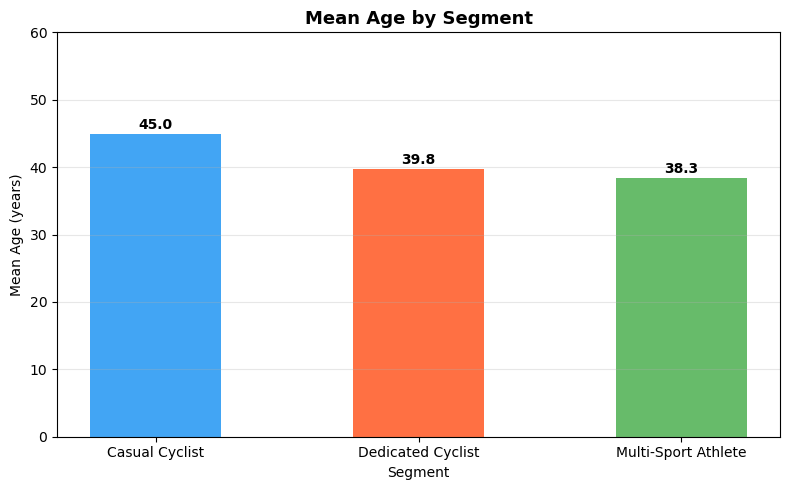

In [18]:
subset_age = data.groupby('cluster')['AGE'].mean().round(2).reset_index()
subset_age['Segment'] = subset_age['cluster'].map(PERSONA_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(subset_age['Segment'], subset_age['AGE'], color=COLORS, alpha=0.85, width=0.5)
ax.set_title('Mean Age by Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Mean Age (years)')
ax.set_ylim(0, 60)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, subset_age['AGE']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/age_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Q3 Analysis — Sports Participation by Segment


In [19]:
df_q3 = data.groupby('cluster')[all_psychographic_columns].mean().round(2).reset_index()
df_q3 = df_q3.melt(id_vars='cluster', var_name='question', value_name='mean_score')
df_q3 = df_q3.pivot(index='question', columns='cluster', values='mean_score').reset_index()
df_q3.columns.name = None
df_q3.columns = ['question'] + [PERSONA_NAMES[c] for c in range(optimal_k)]
df_q3.round(2)

,question,Casual Cyclist,Dedicated Cyclist,Multi-Sport Athlete
0,Q1_1,2.52,2.38,2.82
1,Q1_2,3.38,2.78,2.69
2,Q2_1,3.49,3.88,4.41
3,Q2_2,4.10,3.83,4.35
4,QS6_1,0.00,0.02,0.00
5,QS6_10,0.61,0.44,0.55
6,QS6_11,0.21,0.34,0.50
7,QS6_2,0.49,0.32,0.54
8,QS6_3,0.34,0.43,0.77
9,QS6_4,0.81,0.15,0.54


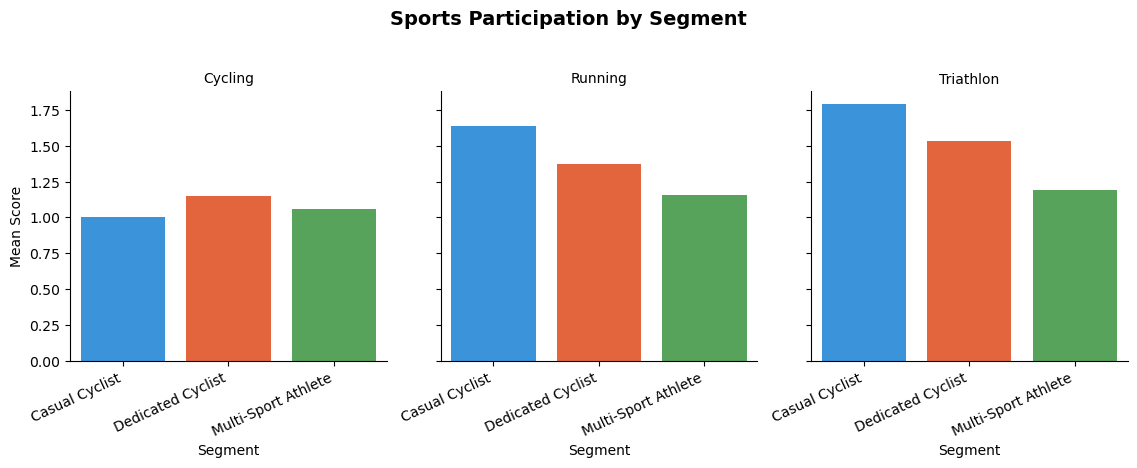

In [20]:
sport_labels = {'hqCycle': 'Cycling', 'hqRun': 'Running', 'hqTri': 'Triathlon'}
sport_features = list(sport_labels.keys())

df_sports = (
    data.groupby('cluster')[sport_features]
    .mean().round(2)
    .reset_index()
    .melt(id_vars='cluster', var_name='Sport', value_name='Mean Score')
)
df_sports['Sport'] = df_sports['Sport'].map(sport_labels)
df_sports['Segment'] = df_sports['cluster'].map(PERSONA_NAMES)

segment_order = list(PERSONA_NAMES.values())
palette = dict(zip(segment_order, COLORS))

g = sns.catplot(
    data=df_sports, x='Segment', y='Mean Score', col='Sport',
    kind='bar', palette=palette, hue='Segment', hue_order=segment_order,
    order=segment_order, height=4.5, aspect=0.85, legend=False
)
g.set_titles('{col_name}', fontsize=12)
g.set_axis_labels('Segment', 'Mean Score')
g.set_xticklabels(rotation=25, ha='right')
plt.suptitle('Sports Participation by Segment', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('figures/sports_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Strategic Recommendations

Based on the segmentation, Wahoo's growth strategy should focus on deepening relationships with existing high-value customers rather than broadening to lower-value segments.

---

### Multi-Sport Athlete (Cluster 2) — Highest Priority
*Highest CLV. Triathlon-focused. Premium equipment buyer. Broad product engagement.*

This segment is Wahoo's target customer. They participate in all three sports, invest heavily in equipment, and are the least price-sensitive. The opportunity is to expand product and service offerings that meet their existing appetite — recovery tracking, advanced multi-sport metrics, and ecosystem integrations (e.g., TrainingPeaks, Zwift). Premium pricing is appropriate and expected by this segment.

---

### Dedicated Cyclist (Cluster 1) — High Priority
*High CLV. Outdoor cycling specialist. Data-driven. Owns bike trainers and GPS computers.*

This segment aligns directly with Wahoo's hardware lineup (ELEMNT cycling computers, KICKR bike trainers). The opportunity is to expand services around the equipment they already value — software features for route planning, performance analysis, and structured training. Cross-sell opportunities exist toward heart rate monitors and power meters as logical next purchases.

---

### Casual Cyclist (Cluster 0) — Low Priority
*Low CLV. Price-sensitive. Indoor cycling focus. Does not engage with performance data.*

This segment does not align with Wahoo's "tip of the spear" mentality. They are more likely to own a spin bike than a GPS cycling computer, respond poorly to performance-focused messaging, and are sensitive to price. Wahoo should avoid over-investing marketing resources here. If targeted at all, entry-level or bundled pricing may be the only viable approach.
